# PrO + Bayesian for our DAG Model

## BGe Model

Let $Y = (y_1,\ldots, y_n)$ be the observed data, where each $y_i \in \mathbb{R}^d$ is a row vector.  
Let $G$ be a DAG on nodes $\{1,\dots,d\}$ with parent set $\pi(j)$ for node $j$.

Under the Gaussian DAG model associated with $G$, the joint distribution of each $y_i$ is multivariate normal
$$
y_i \mid \mu,\Sigma,G \sim \mathcal{N}_d(\mu,\Sigma), \quad i=1,\ldots,n,
$$
with $\mathcal{N}_d(\mu,\Sigma)$ Markov with respect to $G$. Equivalently, this can be written in local (regression) form as
$$
y_{ij} \mid y_{i,\pi(j)}, \theta_j, G \sim \mathcal{N}\!\big( \beta_{j0} + \beta_j^\top y_{i,\pi(j)},\, \sigma_j^2 \big),
$$
where $\theta_j = (\beta_{j0},\beta_j,\sigma_j^2)$ are the parameters of node $j$.

The collection of all parameters is denoted by $\theta$ (e.g., $\theta = (\mu,\Sigma)$ in the global parameterisation, or $\theta = (\theta_1,\dots,\theta_d)$ in the local regression parameterisation).

The posterior predictive distribution of new data points $Y^* = (y_1^*,\ldots,y_m^*)$ is
$$
p(Y^* \mid Y, G) = \int p(Y^* \mid \theta, G)\, p(\theta \mid Y, G)\, d\theta,
$$
which assumes conditional independence of the new observations given the parameters.

In practice, the BGe formulation uses a global Normal–inverse–Wishart prior on $(\mu,\Sigma)$, which induces local conjugate priors on the regression parameters $\theta_j$.

---

### Global Gaussian Likelihood

Conditionally on $(\mu,\Sigma)$,
$$
p(Y \mid \mu,\Sigma,G) = \prod_{i=1}^n \mathcal{N}_d(y_i \mid \mu,\Sigma),
$$
so that $Y$ is an i.i.d.\ sample from $\mathcal{N}_d(\mu,\Sigma)$.  
The DAG $G$ constrains $\Sigma$ (or its inverse) so that the resulting Gaussian is Markov w.r.t.\ $G$ and ensures factorisation of the marginal likelihood $p(Y\mid G)$.

---

### Prior (Normal–Inverse–Wishart)

We place a Normal–inverse–Wishart prior on $(\mu,\Sigma)$:
$$
p(\mu, \Sigma \mid G) 
= p(\mu \mid \Sigma, G)\, p(\Sigma \mid G),
$$
where
- $p(\mu \mid \Sigma, G) = \mathcal{N}_d\!\big(\mu_0,\, \tfrac{1}{\kappa_0}\Sigma\big)$,
- $p(\Sigma \mid G) = \mathcal{W}^{-1}\!(\nu_0,\, S_0)$,

with hyperparameters $\mu_0 \in \mathbb{R}^d$, $\kappa_0 > 0$, $\nu_0 > d-1$, and $S_0$ positive definite.

This global NIW prior implies (via standard linear regression identities) a conjugate Normal–inverse–Gamma prior for each node’s local parameters $(\beta_{j0},\beta_j,\sigma_j^2)$ depending only on its parent set $\pi(j)$.

---

### Conjugate Posterior for $(\mu,\Sigma)$

Define:
$$
\bar{y} = \frac{1}{n}\sum_{i=1}^n y_i,
\qquad
S = \sum_{i=1}^n (y_i - \bar{y})(y_i - \bar{y})^\top.
$$
Note that $S$ is the scatter matrix, not the sample covariance (which would be $(n-1)^{-1}S$).

Under the NIW prior, the posterior is NIW:
$$
p(\mu, \Sigma \mid Y, G)
= p(\mu \mid \Sigma, Y, G)\, p(\Sigma \mid Y, G),
$$
with
- $p(\mu \mid \Sigma, Y, G) = \mathcal{N}_d(\mu_n,\, \tfrac{1}{\kappa_n}\Sigma)$,
- $p(\Sigma \mid Y, G) = \mathcal{W}^{-1}(\nu_n,\, S_n)$,

and updated hyperparameters:
$$
\kappa_n = \kappa_0 + n,
\qquad
\nu_n = \nu_0 + n,
$$
$$
\mu_n = \frac{\kappa_0 \mu_0 + n \bar{y}}{\kappa_n},
$$
$$
S_n = S_0 + S + \frac{\kappa_0 n}{\kappa_0 + n}\,(\bar{y} - \mu_0)(\bar{y} - \mu_0)^\top.
$$

---

### Posterior Predictive Distribution (Single New Observation)

Given a DAG $G$ and parameters $\theta = (\theta_1,\dots,\theta_d)$, the model
factorises as
$$
p(y \mid \theta, G)
= \prod_{j=1}^d p\bigl(y_j \mid y_{\pi(j)}, \theta_j\bigr),
$$
where $\pi(j)$ is the parent set of node $j$.

For a single new data point $y^*$, the posterior predictive distribution is
$$
p(y^* \mid Y, G)
= \int p(y^* \mid \theta, G)\, p(\theta \mid Y, G)\, d\theta,
$$
with
$$
p(y^* \mid \theta, G)
= \prod_{j=1}^d p\bigl(y_j^* \mid y_{\pi(j)}^*, \theta_j\bigr).
$$

Under the global Normal–Inverse–Wishart prior on $(\mu,\Sigma)$, this induces,
for each family
$$
U_j = \{j\} \cup \pi(j),
$$
a local Normal–Inverse–Wishart posterior on $(\mu_{U_j}, \Sigma_{U_j})$. The
corresponding **joint predictive** for the family $y_{U_j}^* = (y_j^*, y_{\pi(j)}^*)$
is a multivariate $t$ distribution:
$$
y_{U_j}^* \mid Y, G \sim
t_{\nu_n - |U_j| + 1}\!\left(
    \mu_{n,U_j},\;
    \frac{\kappa_n + 1}{\kappa_n(\nu_n - |U_j| + 1)}\, S_{n,U_j}
\right),
$$
where $\mu_{n,U_j}$ and $S_{n,U_j}$ are the NIW posterior hyperparameters
restricted to the coordinates in $U_j$, and
$$
\kappa_n = \kappa_0 + n, \qquad \nu_n = \nu_0 + n.
$$

The full DAG predictive then factorises as
$$
p(y^* \mid Y, G)
= \prod_{j=1}^d p\bigl(y_j^* \mid y_{\pi(j)}^*, Y, G\bigr),
$$
where each conditional term $p(y_j^* \mid y_{\pi(j)}^*, Y, G)$ is obtained by
taking the conditional distribution of $y_j^*$ given $y_{\pi(j)}^*$ under the
multivariate $t$ predictive on $U_j$.

---

### DAG Factorisation and Local BGe Score

Although the model is defined globally through $(\mu,\Sigma)$, the Gaussian Markov property and NIW prior imply that the log marginal likelihood decomposes over nodes:
$$
\log p(Y \mid G)
= \sum_{j=1}^d \mathrm{score}_j\!\big( Y_{\{j\} \cup \pi(j)} \big),
$$
where each local score $\mathrm{score}_j(\cdot)$ depends only on the data associated with node $j$ and its parents $\pi(j)$ (through the corresponding sample means and scatter matrices restricted to the variables $\{j\}\cup\pi(j)$).

This decomposability is the key property that makes the BGe score efficiently computable for Bayesian network structure learning.


## Imports

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

## Defining DAGs in JAX

In [2]:
def all_adj_matrices(n: int):
    """
    Generate all directed adjacency matrices for graphs on n labelled nodes.
    Returns array of shape (2^(n*(n-1)), n, n) with boolean entries.
    Self-edges i->i are always 0.
    """
    num_edges = n * (n - 1)
    num_graphs = 1 << num_edges

    # All bit patterns from 0,...,2^(n(n-1))-1
    bits = jnp.arange(num_graphs, dtype=jnp.uint32)

    # Unpack bits -> shape (num_graphs, num_edges)
    bit_matrix = jnp.unpackbits(
        bits[:, None].view(jnp.uint8), axis=1, bitorder="little"
    )
    bit_matrix = bit_matrix[:, :num_edges]  # keep only required bits

    # Insert zeros on the diagonal
    adj = jnp.zeros((num_graphs, n, n), dtype=bool)

    # Fill off-diagonal entries
    k = 0
    for i in range(n):
        for j in range(n):
            if i != j:
                adj = adj.at[:, i, j].set(bit_matrix[:, k].astype(bool))
                k += 1

    return adj


def is_acyclic_vectorised(adj):
    """
    Vectorised cycle check using power-series characterisation:
    A graph is acyclic iff no diagonal entry of A^k is nonzero for k=1..n.
    """
    n = adj.shape[1]
    A = adj.astype(int)

    # Use adjacency powers: A, A^2, ..., A^n
    def scan_body(Ak, _):
        Ak = Ak @ A
        return Ak, Ak

    _, powers = jax.lax.scan(scan_body, A, None, length=n)

    # Check diagonal entries across all powers
    diag_nonzero = jnp.any(jnp.any(jnp.diagonal(powers, axis1=2, axis2=3) > 0, axis=0), axis=1)
    return ~diag_nonzero  # True = acyclic


def enumerate_dags(n: int):
    """
    Returns array of shape (num_dags, n, n) with all DAGs on n labelled nodes.
    Fully vectorised; no Python loops over graphs.
    """
    adj_all = all_adj_matrices(n)
    acyclic_mask = is_acyclic_vectorised(adj_all)
    return adj_all[acyclic_mask]



In [ ]:
def gg(y, a, b):
    x

In [25]:
beta.ppf(x, a, b)

array([0.        , 0.11510942, 0.12162375, 0.12573969, 0.12881488,
       0.13129696, 0.13339233, 0.13521411, 0.13683133, 0.13828941,
       0.13961984, 0.14084546, 0.14198336, 0.14304665, 0.14404568,
       0.14498871, 0.14588249, 0.14673257, 0.14754362, 0.14831954,
       0.1490637 , 0.14977896, 0.15046784, 0.1511325 , 0.15177486,
       0.1523966 , 0.15299923, 0.15358407, 0.15415234, 0.1547051 ,
       0.15524334, 0.15576792, 0.15627966, 0.15677928, 0.15726745,
       0.1577448 , 0.15821187, 0.1586692 , 0.15911726, 0.15955649,
       0.15998732, 0.16041012, 0.16082525, 0.16123305, 0.16163382,
       0.16202786, 0.16241544, 0.16279682, 0.16317224, 0.16354193,
       0.1639061 , 0.16426494, 0.16461867, 0.16496744, 0.16531144,
       0.16565083, 0.16598575, 0.16631636, 0.1666428 , 0.16696519,
       0.16728367, 0.16759834, 0.16790934, 0.16821676, 0.1685207 ,
       0.16882128, 0.16911858, 0.1694127 , 0.16970372, 0.16999172,
       0.17027679, 0.17055901, 0.17083844, 0.17111517, 0.17138

In [26]:
def beta_pdf_level(a, b, h, num_points=2000):
    from scipy.stats import beta
    from scipy.optimize import brentq
    import numpy as np
    
    f = lambda x: beta.pdf(x, a, b) - h
    
    xs = np.linspace(0, 1, num_points)
    fs = f(xs)
    
    sign_changes = np.where(np.diff(np.sign(fs)) != 0)[0]
    
    roots = []
    for idx in sign_changes:
        roots.append(brentq(f, xs[idx], xs[idx+1]))
    return roots


beta_pdf_level(21, 69, 2.5)

[0.16145531531024382, 0.30357114428227433]

CDF between 0.1488 and 0.3212 is 0.9501
[1.35 1.35]


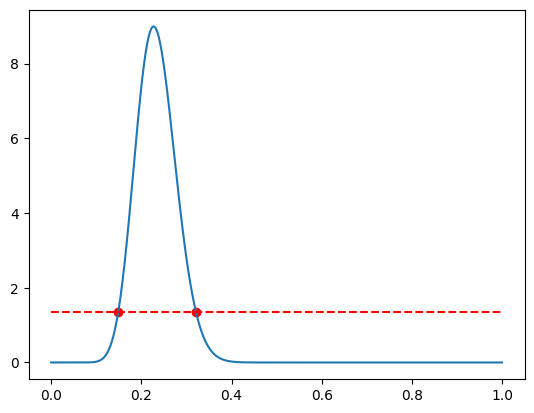

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

a, b = 21, 69
x = np.linspace(0, 1, 1000)
pdf_vals = beta.pdf(x, a, b)

h = 1.35
l, u = beta_pdf_level(a, b, h)

plt.plot(x, pdf_vals)
plt.hlines(h, x[0], x[-1],  color='red', linestyle='--')
pdf_vals = beta.pdf(np.array([l, u]), a, b)
plt.scatter([l, u], pdf_vals, color='red')

cdf = beta.cdf(u, a, b) - beta.cdf(l, a, b)
print(f"CDF between {l:.4f} and {u:.4f} is {cdf:.4f}")
print(pdf_vals)

CDF between 0.1520 and 0.3167 is 0.9386
[1.6 1.6]
0.024326833186353758 0.962962497029556


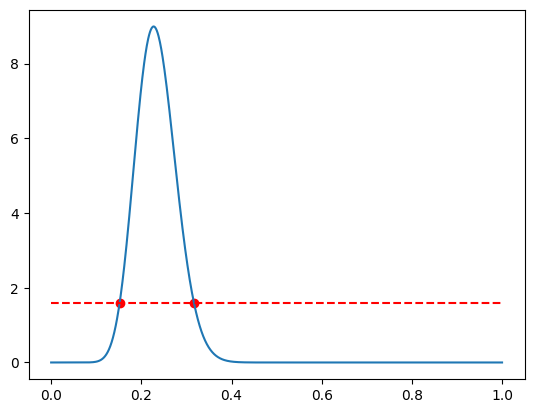

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

a, b = 21, 69
x = np.linspace(0, 1, 1000)
pdf_vals = beta.pdf(x, a, b)

h = 1.6
l, u = beta_pdf_level(a, b, h)

plt.plot(x, pdf_vals)
plt.hlines(h, x[0], x[-1],  color='red', linestyle='--')
pdf_vals = beta.pdf(np.array([l, u]), a, b)
plt.scatter([l, u], pdf_vals, color='red')

cdf = beta.cdf(u, a, b) - beta.cdf(l, a, b)
print(f"CDF between {l:.4f} and {u:.4f} is {cdf:.4f}")
print(pdf_vals)
print(beta.cdf(l, a, b), beta.cdf(u, a, b))

0.225 \pm 1.96\sqrt{\frac{0.225\cdot 0.775}{80}}

In [59]:
1.96 * (0.225 * (1 - 0.225) / 80) ** 0.5 

0.09150676204521718

In [57]:
0.225 - 1.96 * (0.225 * (1 - 0.225) / 80) ** 0.5

0.13349323795478282

In [7]:
dags_3 = enumerate_dags(3)
print(f"Number of DAGs on 3 nodes: {dags_3.shape[0]}")  # Should be 25

Number of DAGs on 3 nodes: 25


In [15]:
dags_3 = enumerate_dags(5)
print(f"Number of DAGs on 3 nodes: {dags_3.shape[0]}")  # Should be 25

Number of DAGs on 3 nodes: 29281


## Posterior + Posterior Predictive Update formulae

In [ ]:
from typing import NamedTuple, Tuple
from jax import Array, random, lax
import jax.numpy as jnp
import jax.scipy as jsp


class NIWHypers(NamedTuple):
    mu: Array      # (d,)
    kappa: float
    nu: float
    S: Array       # (d, d)


class TPredParams(NamedTuple):
    df: float      # degrees of freedom
    loc: Array     # (k,)
    scale: Array   # (k, k)


class TPred1DParams(NamedTuple):
    df: float      # degrees of freedom
    loc: float     # mean
    scale: float   # variance


# ---------- NIW posterior + predictive (global or restricted) ----------

def niw_posterior(
    Y: Array,          # (n, d)
    prior: NIWHypers,
) -> NIWHypers:
    mu0, kappa0, nu0, S0 = prior

    n, d = Y.shape
    ybar = jnp.mean(Y, axis=0)        # (d,)

    Y_centered = Y - ybar
    S = Y_centered.T @ Y_centered     # (d, d)

    kappa_n = kappa0 + n
    nu_n = nu0 + n
    mu_n = (kappa0 * mu0 + n * ybar) / kappa_n

    diff = (ybar - mu0)[..., None]    # (d, 1)
    S_n = S0 + S + (kappa0 * n / kappa_n) * (diff @ diff.T)

    return NIWHypers(mu=mu_n, kappa=kappa_n, nu=nu_n, S=S_n)


def niw_predictive_params(
    post: NIWHypers,
) -> TPredParams:
    mu_n, kappa_n, nu_n, S_n = post
    d = mu_n.shape[0]

    df = nu_n - d + 1
    scale = ((kappa_n + 1.0) / (kappa_n * df)) * S_n

    return TPredParams(df=df, loc=mu_n, scale=scale)


# ---------- DAG utilities ----------

def parents_of(j: int, G: Array) -> Array:
    return jnp.where(G[:, j])[0]


def family_indices(j: int, G: Array) -> Array:
    pars = parents_of(j, G)
    return jnp.concatenate([jnp.array([j]), pars], axis=0)


def restrict_niw(prior: NIWHypers, U: Array) -> NIWHypers:
    mu0, kappa0, nu0, S0 = prior
    muU = mu0[U]
    S0U = S0[jnp.ix_(U, U)]
    return NIWHypers(mu=muU, kappa=kappa0, nu=nu0, S=S0U)


# ---------- Local family posterior & predictive ----------

def local_family_posterior(
    Y: Array,
    G: Array,
    j: int,
    global_prior: NIWHypers,
) -> Tuple[Array, NIWHypers]:
    U = family_indices(j, G)
    YU = Y[:, U]
    prior_U = restrict_niw(global_prior, U)
    post_U = niw_posterior(YU, prior_U)
    return U, post_U


def local_family_predictive_params(
    Y: Array,
    G: Array,
    j: int,
    global_prior: NIWHypers,
) -> Tuple[Array, TPredParams]:
    U, post_U = local_family_posterior(Y, G, j, global_prior)
    tparams_U = niw_predictive_params(post_U)
    return U, tparams_U


# ---------- Conditional predictive: y_j^* | y_pa(j)^* ----------

def conditional_univariate_t_from_joint(
    tparams: TPredParams,
    y_parents_star: Array,   # (k-1,)
) -> TPred1DParams:
    df_joint, mu, Sigma = tparams
    k = mu.shape[0]
    assert y_parents_star.shape[0] == k - 1

    mu1 = mu[0]
    mu2 = mu[1:]

    Sigma11 = Sigma[0, 0]
    Sigma12 = Sigma[0, 1:]
    Sigma21 = Sigma[1:, 0]
    Sigma22 = Sigma[1:, 1:]

    p2 = k - 1
    diff2 = y_parents_star - mu2
    Sigma22_inv = jnp.linalg.inv(Sigma22)
    d2 = diff2.T @ (Sigma22_inv @ diff2)

    mu_cond = mu1 + Sigma12 @ (Sigma22_inv @ diff2)
    Sigma_cond = Sigma11 - Sigma12 @ (Sigma22_inv @ Sigma21)

    df_cond = df_joint + p2
    scale_cond = ((df_joint + d2) / df_cond) * Sigma_cond

    return TPred1DParams(df=df_cond, loc=float(mu_cond), scale=float(scale_cond))


def node_predictive_params(
    Y: Array,
    G: Array,
    j: int,
    global_prior: NIWHypers,
    y_star: Array,      # (d,)
) -> TPred1DParams:
    U, tparams_U = local_family_predictive_params(Y, G, j, global_prior)
    parents_idx = U[1:]
    y_parents_star = y_star[parents_idx]
    return conditional_univariate_t_from_joint(tparams_U, y_parents_star)


# ---------- Univariate Student-t log PDF ----------

def student_t1_logpdf(x: float, params: TPred1DParams) -> float:
    df, loc, scale = params
    nu = df
    sigma2 = scale
    z = (x - loc) / jnp.sqrt(sigma2)

    # log t pdf: Γ((ν+1)/2) - Γ(ν/2) - 0.5 log(νπσ²) - (ν+1)/2 log(1 + z²/ν)
    log_norm = (
        jsp.special.gammaln((nu + 1.0) / 2.0)
        - jsp.special.gammaln(nu / 2.0)
        - 0.5 * jnp.log(nu * jnp.pi * sigma2)
    )
    log_pdf = log_norm - (nu + 1.0) / 2.0 * jnp.log1p((z * z) / nu)
    return float(log_pdf)


# ---------- Joint predictive log-density: log p(y* | Y, G) ----------

def log_predictive_joint(
    Y: Array,
    G: Array,
    global_prior: NIWHypers,
    y_star: Array,       # (d,)
) -> float:
    """
    Compute log p(y_star | Y, G) = sum_j log p(y_j^* | y_pa(j)^*, Y, G).

    Uses a JAX fori_loop over nodes j (compiled, no Python overhead).
    """
    d = Y.shape[1]

    def body_fun(j, log_acc):
        params_j = node_predictive_params(Y, G, j, global_prior, y_star)
        log_pj = student_t1_logpdf(y_star[j], params_j)
        return log_acc + log_pj

    log_p = lax.fori_loop(0, d, body_fun, 0.0)
    return float(log_p)


# ---------- Example: generate data from a 3-node DAG and test ----------

def simulate_bn_data(
    key: Array,
    n: int,
) -> tuple[Array, Array]:
    """
    Simple 3-node Gaussian BN:
        0 -> 1, 0 -> 2, 1 -> 2

    Structural equations:
        X0 ~ N(0, 1)
        X1 = 0.8 * X0 + e1,   e1 ~ N(0, 0.5^2)
        X2 = 0.5 * X0 + 0.3 * X1 + e2,  e2 ~ N(0, 0.5^2)
    """
    d = 3
    # Adjacency matrix G[i,j] = 1 if i -> j
    G = jnp.array([
        [0, 1, 1],  # 0 -> 1, 0 -> 2
        [0, 0, 1],  # 1 -> 2
        [0, 0, 0],
    ], dtype=bool)

    k0, k1, k2, k3 = random.split(key, 4)

    # X0 ~ N(0,1)
    X0 = random.normal(k0, (n,))

    # X1 | X0
    e1 = 0.5 * random.normal(k1, (n,))
    X1 = 0.8 * X0 + e1

    # X2 | X0, X1
    e2 = 0.5 * random.normal(k2, (n,))
    X2 = 0.5 * X0 + 0.3 * X1 + e2

    Y = jnp.stack([X0, X1, X2], axis=1)  # (n, 3)

    return Y, G



key = random.PRNGKey(0)
n = 200
Y, G = simulate_bn_data(key, n)
d = Y.shape[1]

# Define a simple global NIW prior (on standardised variables this is quite natural)
mu0 = jnp.zeros(d)
kappa0 = 1.0
nu0 = d + 2.0
S0 = jnp.eye(d)

global_prior = NIWHypers(mu=mu0, kappa=kappa0, nu=nu0, S=S0)

# Example new point y_star at which we want the predictive for each node
# (here we just take some arbitrary point, e.g. the empirical mean)
y_star = jnp.mean(Y, axis=0)

# Compute predictive params for each node j
for j in range(d):
    tparams_j = node_predictive_params(Y, G, j, global_prior, y_star)
    print(f"Node {j}: df={tparams_j.df:.2f}, loc={tparams_j.loc:.3f}, scale={tparams_j.scale:.3f}")


[]
Node 0: df=205.00, loc=0.035, scale=1.252
[0.0355694]
Node 1: df=205.00, loc=-0.035, scale=0.233
[ 0.0355694  -0.03562305]
Node 2: df=205.00, loc=0.028, scale=0.257


In [12]:
log_predictive_joint(
    Y,
    G,
    global_prior,
    y_star,
)

ConcretizationTypeError: Abstract tracer value encountered where concrete value is expected: traced array with shape int32[]
The size argument of jnp.nonzero must be statically specified to use jnp.nonzero within JAX transformations.
The error occurred while tracing the function body_fun at /var/folders/y9/f2jq2rkn6h16kl4g9j02c2800000gn/T/ipykernel_71396/1049587891.py:184 for scan. This concrete value was not available in Python because it depends on the value of the argument loop_carry[0].

See https://docs.jax.dev/en/latest/errors.html#jax.errors.ConcretizationTypeError

## PrO Loss